# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

https://1drv.ms/v/c/808ebfd9a0d86213/IQCLY6g2vuPjQr-7RxF_QZK0AWue-PxKWmQ8QlMEtwIh2WA?e=qBwOpD

In [16]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.3 MB/s eta 0:00:00


In [23]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
df_genes = pd.read_csv("./data/df_genes_aula6exer7.csv", index_col="Unnamed: 0")
df_genes.head()

,num_letras,primeiras_duas_letras,num_a,contains_hu
isg15,5,is,0,False
hur,3,hu,0,True
ifna,4,if,1,False
tnfa,4,tn,1,False
atpsf1a,7,at,2,False


In [ ]:
df_genes['id_entrez'] = [
    "NM_005101.4",
    "NM_001419.3",
    "NM_024013.3",
    "NM_001270508.2",
    "NM_004046.6",
]

df_genes['id_protein'] = [
    'NP_005092.1',
    "NP_001410.2",
    "NP_000596.2",
    "NP_001257437.1",
    "NP_004037.1",
]
df_genes

,num_letras,primeiras_duas_letras,num_a,contains_hu,id_entrez,id_protein
isg15,5,is,0,False,NM_005101.4,NP_005092.1
hur,3,hu,0,True,NM_001419.3,NP_001410.2
ifna,4,if,1,False,NM_024013.3,NP_000596.2
tnfa,4,tn,1,False,NM_001270508.2,NP_001257437.1
atpsf1a,7,at,2,False,NM_004046.6,NP_004037.1


In [28]:
import os

def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    # 1. Informar o email (correto)
    Entrez.email = "juliacardoso628@gmail.com"

    # 2. Garantir que a pasta de destino exista para não dar erro de 'FileNotFound'
    caminho_pasta = "./exercicios/data/"
    if not os.path.exists(caminho_pasta):
        os.makedirs(caminho_pasta)
        print(f"Pasta {caminho_pasta} criada com sucesso.")

    try:
        # 3. Busca a sequência no NCBI
        print(f"Buscando {id_protein} no NCBI...")
        handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
        record = handle.read()
        handle.close()

        # 4. Salva o arquivo
        caminho_arquivo = f"{caminho_pasta}{nome_gene}.fasta"
        with open(caminho_arquivo, "w") as f:
            f.write(record)

        print(f"Arquivo {nome_gene}.fasta salvo com sucesso!")

    except Exception as e:
        print(f"Erro ao processar o gene {nome_gene}: {e}")

    return None

In [ ]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)  # Para evitar sobrecarga no servidor do NCBI
    print(nome_gene, id_gene)

isg15 NP_005092.1
hur NP_001410.2
ifna NP_000596.2
tnfa NP_001257437.1
atpsf1a NP_004037.1


In [ ]:
descr_gene = {}
for gene in df_genes.index:
    caminho = f"./exercicios/data/{gene}.fasta"
    with open(caminho, 'r') as file:
        data = file.read()
        data = data.split('\n')
        cod = data[0].split(" ")[0]
        seq = ''.join(data[1:-2])
        descr_gene[gene] = {"gene": gene, "cod": cod, "seq": seq}
descr_gene_df = pd.DataFrame.from_dict(descr_gene, orient='index')
descr_gene_df.head()

,gene,cod,seq
isg15,isg15,>NP_005092.1,MGWDLTVKMLAGNEFQVSLSSSMSVSELKAQITQKIGVHAFQQRLA...
hur,hur,>NP_001410.2,MSNGYEDHMAEDCRGDIGRTNLIVNYLPQNMTQDELRSLFSSIGEV...
ifna,ifna,>NP_000596.2,MALTFALLVALLVLSCKSSCSVGCDLPQTHSLGSRRTLMLLAQMRR...
tnfa,tnfa,>NP_001257437.1,MAEQVLPQALYLSNMRKAVKIRERTPEDIFKPTNGIIHHFKTMHRY...
atpsf1a,atpsf1a,>NP_004037.1,MLSVRVAAAVVRALPRRAGLVSRNALGSSFIAARNFHASNTHLQKT...


In [1]:
dados_gene = {
    'BRCA1': [5, 'BR', 1, False],
    'TP53': [4, 'TP', 0, False],
    'APOE': [4, 'AP', 1, False],
    'MTHFR': [5, 'MT', 0, False],
    'EGFR': [4, 'EG', 0, False]
}

import pandas as pd

df_genes = pd.DataFrame.from_dict(dados_gene, orient='index')
df_genes.columns = ['Tamanho_nucleotideo', 'Sigla_Prefixo', 'Contagem_A', 'Status_HU']
df_genes.to_csv('dados_geneticos.csv')

print("Arquivo 'dados_geneticos.csv' criado com sucesso neste notebook!")

Arquivo 'dados_geneticos.csv' criado com sucesso neste notebook!


In [29]:
import os
import time
import pandas as pd
from Bio import Entrez

Entrez.email = "juliacardoso628@gmail.com"
caminho_pasta = "./exercicios/data/"

if not os.path.exists(caminho_pasta):
    os.makedirs(caminho_pasta)
    print(f"Pasta {caminho_pasta} criada.")

df_genes = pd.DataFrame({
    'id_protein': [
        'NP_005092.1', "NP_001410.2", "NP_000596.2",
        "NP_001257437.1", "NP_004037.1"
    ]
}, index=['IFNG', 'TNF', 'TP53', 'IL6', 'GAPDH'])

def baixar_e_processar():
    descr_gene = {}

    for nome_gene in df_genes.index:
        id_prot = df_genes.loc[nome_gene, "id_protein"]

        try:
            print(f"Baixando {nome_gene} ({id_prot})...")
            handle = Entrez.efetch(db="protein", id=id_prot, rettype="fasta", retmode="text")
            record = handle.read()
            handle.close()

            with open(f"{caminho_pasta}{nome_gene}.fasta", "w") as f:
                f.write(record)

            linhas = record.split('\n')
            cod = linhas[0].split(" ")[0].replace(">", "")
            seq = "".join([l.strip() for l in linhas[1:]])

            descr_gene[nome_gene] = {"gene": nome_gene, "cod": cod, "seq": seq}
            print(f"OK: {nome_gene} processado.")

            time.sleep(2)

        except Exception as e:
            print(f"Erro no gene {nome_gene}: {e}")

    return pd.DataFrame.from_dict(descr_gene, orient='index')

descr_gene_df = baixar_e_processar()

if not descr_gene_df.empty:
    print("\n--- SUCESSO ---")
    print("O descr_gene_df foi criado com sucesso!")
    print(descr_gene_df.head())
else:
    print("\n--- ATENÇÃO ---")
    print("O DataFrame continua vazio.")

Pasta ./exercicios/data/ criada.
Baixando IFNG (NP_005092.1)...
OK: IFNG processado.
Baixando TNF (NP_001410.2)...
OK: TNF processado.
Baixando TP53 (NP_000596.2)...
OK: TP53 processado.
Baixando IL6 (NP_001257437.1)...
OK: IL6 processado.
Baixando GAPDH (NP_004037.1)...
OK: GAPDH processado.

--- SUCESSO ---
O descr_gene_df foi criado com sucesso!
        gene             cod  \
IFNG    IFNG     NP_005092.1   
TNF      TNF     NP_001410.2   
TP53    TP53     NP_000596.2   
IL6      IL6  NP_001257437.1   
GAPDH  GAPDH     NP_004037.1   

                                                     seq  
IFNG   MGWDLTVKMLAGNEFQVSLSSSMSVSELKAQITQKIGVHAFQQRLA...  
TNF    MSNGYEDHMAEDCRGDIGRTNLIVNYLPQNMTQDELRSLFSSIGEV...  
TP53   MALTFALLVALLVLSCKSSCSVGCDLPQTHSLGSRRTLMLLAQMRR...  
IL6    MAEQVLPQALYLSNMRKAVKIRERTPEDIFKPTNGIIHHFKTMHRY...  
GAPDH  MLSVRVAAAVVRALPRRAGLVSRNALGSSFIAARNFHASNTHLQKT...  


DataFrame com a coluna de frequência:
       Tamanho_nucleotideo Sigla_Prefixo  Contagem_A  Status_HU  \
BRCA1                    5            BR           1      False   
TP53                     4            TP           0      False   
APOE                     4            AP           1      False   
MTHFR                    5            MT           0      False   
EGFR                     4            EG           0      False   

       Frequencia_tam_nome  
BRCA1                    2  
TP53                     3  
APOE                     3  
MTHFR                    2  
EGFR                     3  


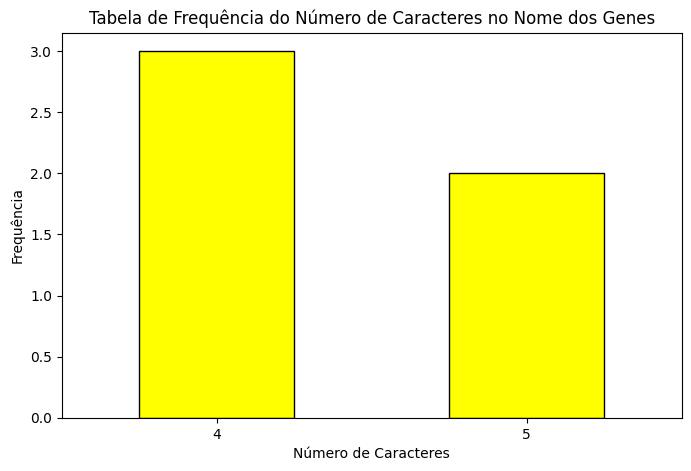

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_genes = pd.read_csv('dados_geneticos.csv', index_col=0)

contagem_caracteres = df_genes.index.str.len()
tabela_freq = contagem_caracteres.value_counts()
df_genes['Frequencia_tam_nome'] = df_genes.index.str.len().map(tabela_freq)

print("DataFrame com a coluna de frequência:")
print(df_genes)

plt.figure(figsize=(8, 5))
tabela_freq.plot(kind='bar', color='yellow', edgecolor='black')

plt.title('Tabela de Frequência do Número de Caracteres no Nome dos Genes')
plt.xlabel('Número de Caracteres')
plt.ylabel('Frequência')
plt.xticks(rotation=0)
plt.show()

## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [31]:
import pandas as pd

dados_aa = {
    'Aminoacido': ['Alanina', 'Arginina', 'Asparagina', 'Aspartato', 'Cisteína', 'Glutamato', 'Glutamina', 'Glicina', 'Histidina', 'Isoleucina', 'Leucina', 'Lisina', 'Metionina', 'Fenilalanina', 'Prolina', 'Serina', 'Treonina', 'Triptofano', 'Tirosina', 'Valina'],
    'Sigla': ['A', 'R', 'N', 'D', 'C', 'E', 'Q', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
}
df_aminoacidos = pd.DataFrame(dados_aa)

def contar_frequencia_aa(sequencia):
    letras_aa = "ARNDCEQGHILKMFPSTWYV"
    seq_limpa = str(sequencia).upper()
    return {aa: seq_limpa.count(aa) for aa in letras_aa}


    frequencias_dict = {}
    for gene in descr_gene_df.index:
        sequencia = descr_gene_df.loc[gene, 'seq']
        frequencias_dict[gene] = contar_frequencia_aa(sequencia)

    df_frequencia_absoluta = pd.DataFrame.from_dict(frequencias_dict, orient='index')
    print("Tabela de Frequência Absoluta criada.")
    print(df_frequencia_absoluta.head())


Tabela de Frequência Absoluta criada.
        A   R   N   D   C   E   Q   G   H   I   L   K   M   F   P   S   T  W  \
IFNG    7   8   4   7   1   9  12  18   3   3  24   8   4   5   8  15   9  2   
TNF    23  20  23  16   3  15  12  29   8  19  22  18  10  18  12  28  16  2   
TP53   11  10   4   8   6  14  12   6   3   8  27  11   6  11   5  18  11  2   
IL6    50  56  40  30  40  57  39  45  30  27  64  46  20  34  56  53  47  9   
GAPDH  58  38  16  29   2  31  25  51   7  39  53  30  12  16  18  39  27  0   

        Y   V  
IFNG    2  16  
TNF    10  22  
TP53    5  10  
IL6    18  29  
GAPDH  16  46  


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [32]:
valinas_por_gene = df_frequencia_absoluta['V']
print("Número de Valinas por Gene:")
print(valinas_por_gene)

gene_max_valina = valinas_por_gene.idxmax()
quantidade_max = valinas_por_gene.max()

print(f"\nGene com o maior número de Valinas é o '{gene_max_valina}' com '{quantidade_max}' resíduos.")


Número de Valinas por Gene:
IFNG     16
TNF      22
TP53     10
IL6      29
GAPDH    46
Name: V, dtype: int64

Gene com o maior número de Valinas é o 'GAPDH' com '46' resíduos.


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [33]:
serinas = df_frequencia_absoluta['S']

media_S = serinas.mean()
mediana_S = serinas.median()
moda_S = serinas.mode().tolist()

print(f"Média de Serinas: {media_S}")
print(f"Mediana de Serinas: {mediana_S}")
print(f"Moda de Serinas: {moda_S}")

Média de Serinas: 30.6
Mediana de Serinas: 28.0
Moda de Serinas: [15, 18, 28, 39, 53]


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

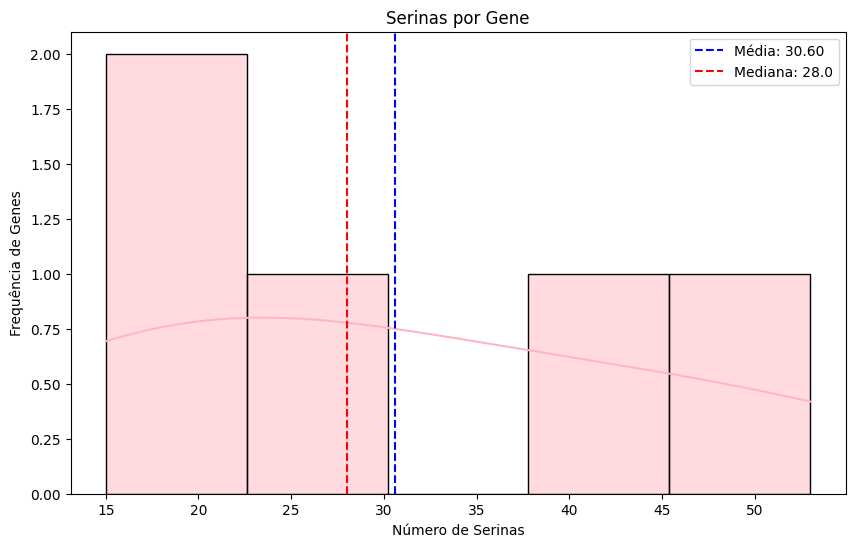

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

serinas = df_frequencia_absoluta['S']
media = serinas.mean()
mediana = serinas.median()

plt.figure(figsize=(10, 6))
sns.histplot(serinas, kde=True, color= 'lightpink', bins=5)

plt.axvline(media, color='blue', linestyle='--', label=f'Média: {media:.2f}')
plt.axvline(mediana, color='red', linestyle='--', label=f'Mediana: {mediana}')

plt.title('Serinas por Gene')
plt.xlabel('Número de Serinas')
plt.ylabel('Frequência de Genes')
plt.legend()

plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

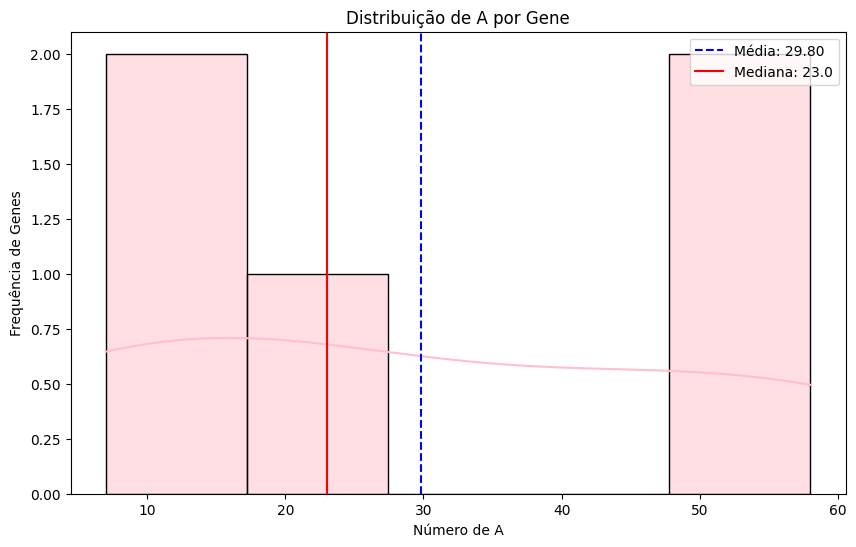

{'Média': np.float64(29.8), 'Mediana': 23.0}

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

def analisar_aminoacido(sigla_aa):
    if sigla_aa not in df_frequencia_absoluta.columns:
        print(f"Aminoácido '{sigla_aa}' não encontrado.")
        return

    dados = df_frequencia_absoluta[sigla_aa]
    media = dados.mean()
    mediana = dados.median()

    plt.figure(figsize=(10, 6))
    sns.histplot(dados, kde=True, color='pink', bins=5)
    plt.axvline(media, color='blue', linestyle='--', label=f'Média: {media:.2f}')
    plt.axvline(mediana, color='red', linestyle='-', label=f'Mediana: {mediana}')
    plt.title(f'Distribuição de {sigla_aa} por Gene')
    plt.xlabel(f'Número de {sigla_aa}')
    plt.ylabel('Frequência de Genes')
    plt.legend()
    plt.show()

    return {"Média": media, "Mediana": mediana}

analisar_aminoacido('A')


## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

--- Glutamina (Q) ---


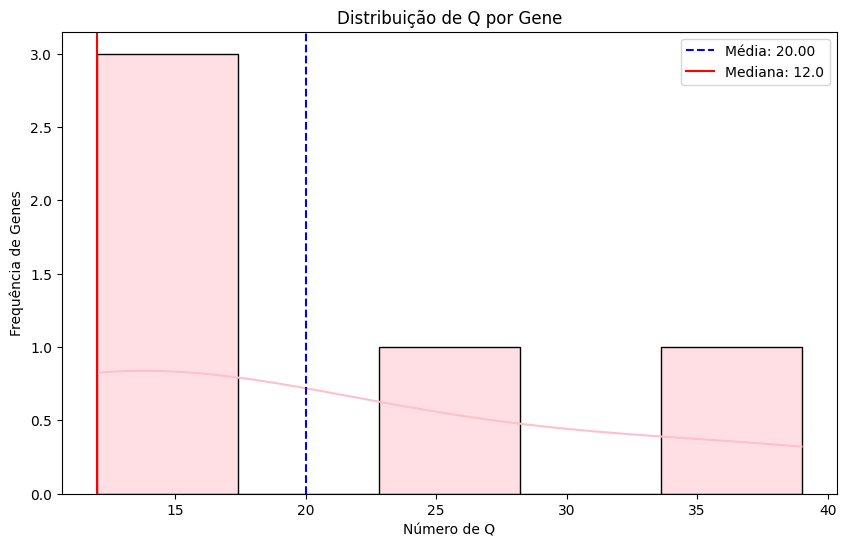


--- Glicina (G) ---


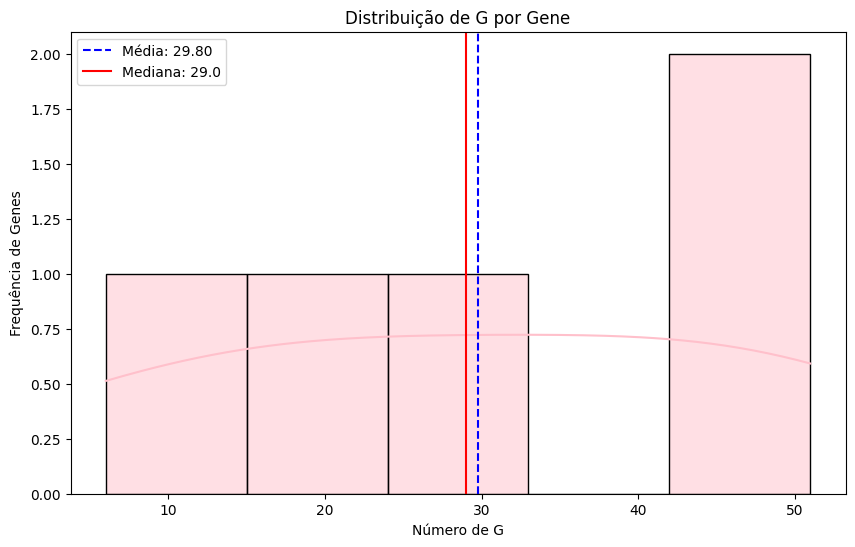


--- Lisina (K) ---


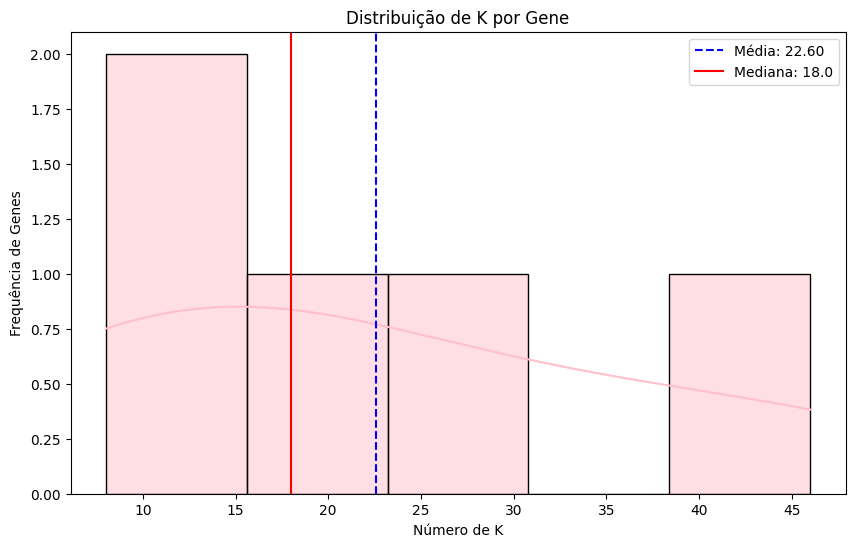


--- Valina (V) ---


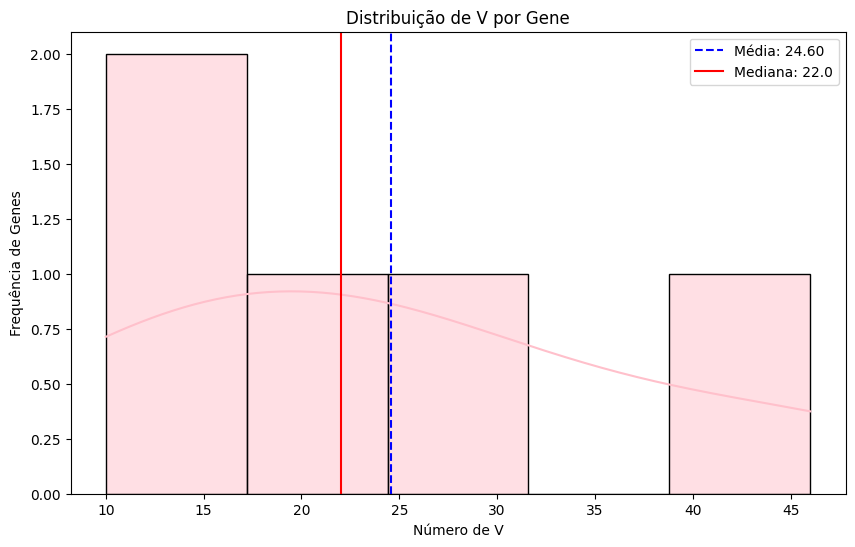


--- Resultado Final ---
Aminoácido Q: Diferença entre Média e Mediana = 8.0
Aminoácido G: Diferença entre Média e Mediana = 0.8000000000000007
Aminoácido K: Diferença entre Média e Mediana = 4.600000000000001
Aminoácido V: Diferença entre Média e Mediana = 2.6000000000000014


In [40]:
print("--- Glutamina (Q) ---")
res_q = analisar_aminoacido('Q')

print("\n--- Glicina (G) ---")
res_g = analisar_aminoacido('G')

print("\n--- Lisina (K) ---")
res_k = analisar_aminoacido('K')

print("\n--- Valina (V) ---")
res_v = analisar_aminoacido('V')

resultados = {'Q': res_q, 'G': res_g, 'K': res_k, 'V': res_v}
diferencas = {aa: abs(val['Média'] - val['Mediana']) for aa, val in resultados.items()}

min_dif_aa: min(diferencas, key=diferencas.get)

print("\n--- Resultado Final ---")
for aa, dif in diferencas.items():
    print(f"Aminoácido {aa}: Diferença entre Média e Mediana = {dif}")

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [43]:
cisteinas_top3 = df_frequencia_absoluta['C'].iloc[:3]

media_C = cisteinas_top3.mean()
mediana_C = cisteinas_top3.median()

print(f"Média de Cisteína dos três primeiros genes: {media_C}")
print(f"Mediana de Cisteína dos três primeiros genes: {mediana_C}")




Média de Cisteína dos três primeiros genes: 3.3333333333333335
Mediana de Cisteína dos três primeiros genes: 3.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [45]:
media_por_gene = df_frequencia_absoluta.mean(axis=1)

maior_gene = media_por_gene.idxmax()
maior_valor = media_por_gene.max()

print(f"O maior gene é o {maior_gene}, com uma média de {maior_valor:.2f} aminoácidos por resíduo.")

O maior gene é o IL6, com uma média de 39.50 aminoácidos por resíduo.


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [46]:
media_por_gene = df_frequencia_absoluta.mean(axis=1)

menor_gene = media_por_gene.idxmin()
menor_valor = media_por_gene.min()

print(f"O menor gene é o {menor_gene}, com uma média de {menor_valor:.2f} aminoácidos por resíduo.")

O menor gene é o IFNG, com uma média de 8.25 aminoácidos por resíduo.
